In [2]:
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os
from sqlalchemy import create_engine

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [3]:
category_rev = ''' WITH product_catt AS (SELECT product_id, product_category_name_english AS product_category
                                            FROM products AS p
                                            INNER JOIN product_category_name_translation AS pct
                                            ON p.product_category_name = pct.product_category_name)
                        SELECT pc.product_category, ROUND(AVG(orv.review_score),2) AS rating , COUNT(DISTINCT oi.order_id) AS orders
                        FROM order_items as oi
                        INNER JOIN order_reviews AS orv
                        ON oi.order_id = orv.order_id
                        INNER JOIN product_catt AS pc
                        ON oi.product_id = pc.product_id
                        GROUP BY pc.product_category
                        HAVING COUNT(DISTINCT oi.order_id) >= 30
                        ORDER BY rating DESC;'''

category_rev_df = pd.read_sql(category_rev,engine)

This will give us product_categories with their average ratings and order count, ordered according to their rating

In [4]:
top_product_cat = category_rev_df.head(10)
bottom_product_cat = category_rev_df.tail(10)

Now we have two dataframes showing us the Top 10 and Bottom 10 Product Categories by review score along with the number of orders placed in each category. 

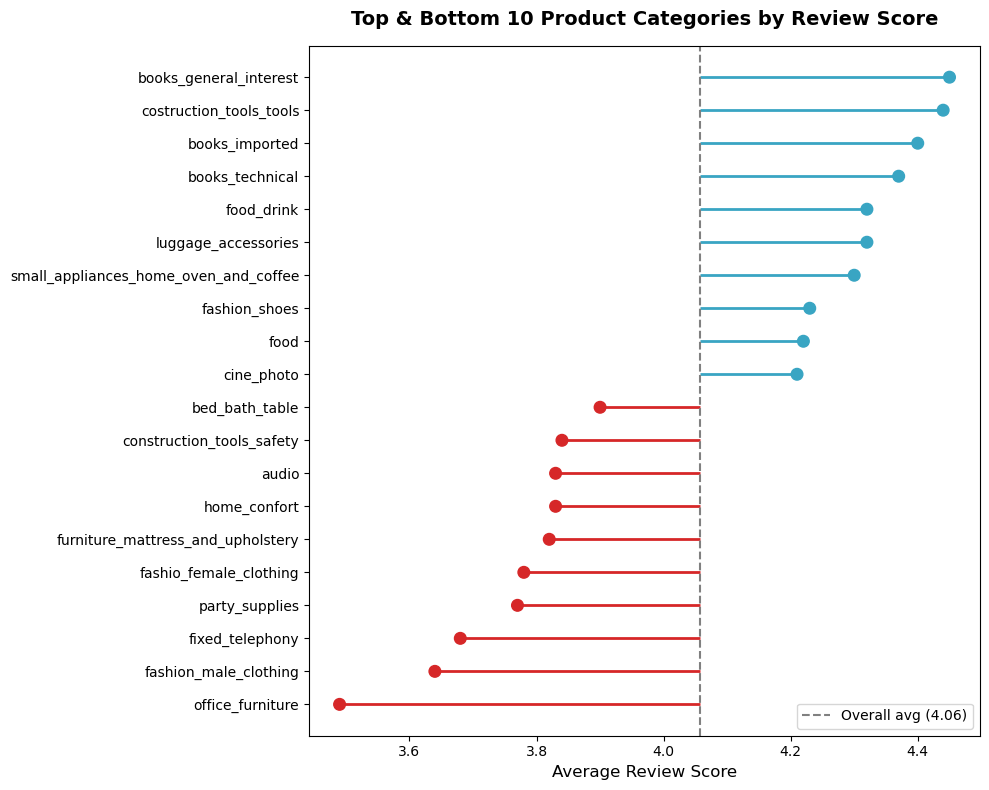

In [5]:
overall_avg = category_rev_df['rating'].mean()

combined = pd.concat([top_product_cat, bottom_product_cat]).sort_values('rating')
colors = ['#d62728' if v < overall_avg else "#39a5c3" for v in combined['rating']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.hlines(y=combined['product_category'], xmin=overall_avg, xmax=combined['rating'],
          color=colors, linewidth=2)
ax.scatter(combined['rating'], combined['product_category'], color=colors, s=70, zorder=3)
ax.axvline(overall_avg, color='gray', linestyle='--', label=f'Overall avg ({overall_avg:.2f})')
ax.set_xlabel('Average Review Score',fontsize=12)
ax.set_title('Top & Bottom 10 Product Categories by Review Score',fontsize=14,pad=15,weight='bold')
ax.legend(loc=4)
plt.tight_layout()
plt.show()

Overall avg is the mean of review score of all product categories. This chart shows us the Top & Bottom 10 product categories as how well they perform against that average.<br>
One key insight we can take away from this is that the top product categories consist of small items like books, small appliances, etc. Meanwhile, the bottom product categories consist of large items like office furniture, bed tables, and similar goods. This difference likely relates to delivery logistics: large items take more time to deliver and have a higher chance of getting damaged midway than small items.

In [7]:
# Exporting dataframe to csv for use in Tableau
combined.to_csv('/Volumes/Air/Olist_exports_tableau/Product_category_rating.csv', index=False)